# 기본 모델만 사용

사용 디바이스: cuda
총 데이터 수: 2199

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5299.71it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝
Epoch  1 | Train Acc 58.7% (F1 0.5786) | Val Acc 65.9% (F1 0.6071) | Test Acc 68.0% (F1 0.6429)
Epoch  2 | Train Acc 78.7% (F1 0.7867) | Val Acc 80.1% (F1 0.8000) | Test Acc 82.0% (F1 0.8194)
Epoch  3 | Train Acc 86.1% (F1 0.8607) | Val Acc 81.8% (F1 0.8182) | Test Acc 84.8% (F1 0.8477)
Epoch  4 | Train Acc 89.8% (F1 0.8975) | Val Acc 78.4% (F1 0.7823) | Test Acc 83.6% (F1 0.8353)
Epoch  5 | Train Acc 92.5% (F1 0.9254) | Val Acc 80.1% (F1 0.8010) | Test Acc 87.3% (F1 0.8727)
Epoch  6 | Train Acc 94.9% (F1 0.9494) | Val Acc 79.5% (F1 0.7942) | Test Acc 84.3% (F1 0.8428)
Epoch  7 | Train Acc 95.8% (F1 0.9583) | Val Acc 81.2% (F1 0.8115) | Test Acc 83.4% (F1 0.8334)
Epoch  8 | Train Acc 95.8% (F1 0.9577) | Val Acc 81.2% (F1 0.8118) | Test Acc 83.6% (F1 0.8357)
Epoch  9 | Train Acc 98.0% (F1 0.9804) | Val Acc 83.0% (F1 0.8295) | Test Acc 84.8% (F1 0.8477)
Epoch 10 | Train Acc 97.8% (F1 0.9779) | Val Acc 85.2% (F1 0.8523) | Test Acc 85.9% (F1 0.8590)
Epoch 11 | Train Acc 98.5% (F1 0.9

특징 추출: 100%|██████████| 138/138 [00:02<00:00, 59.89it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


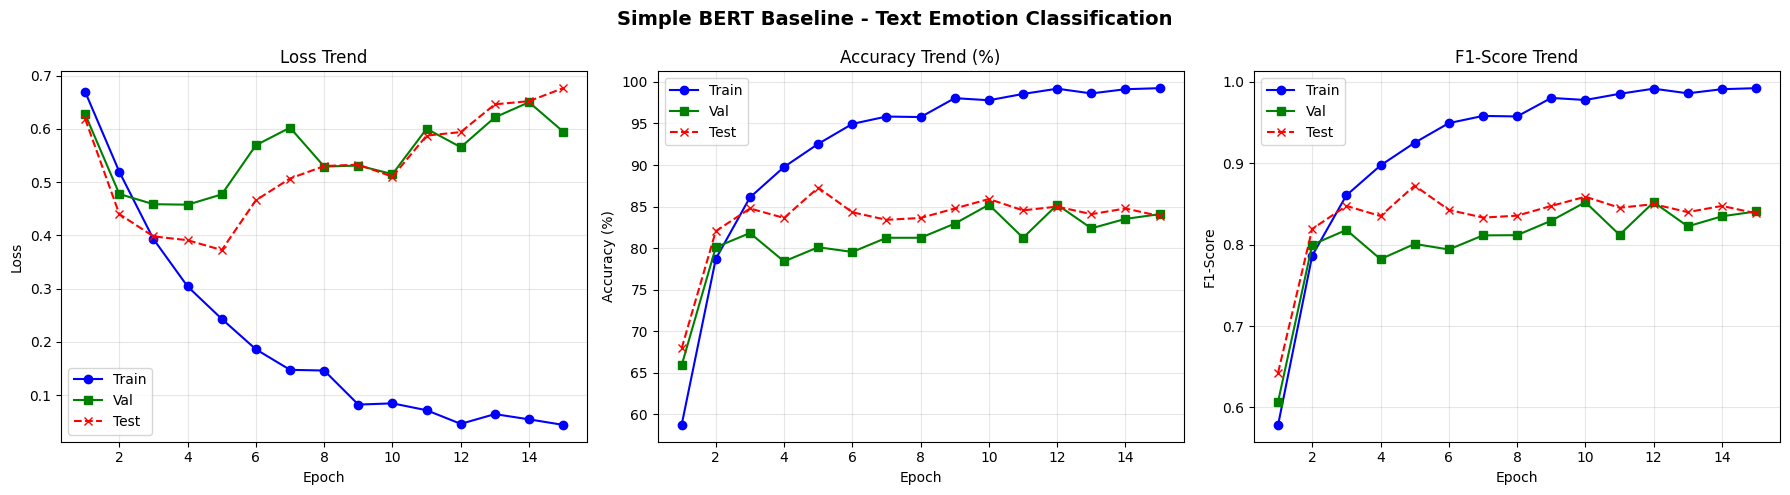

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드
text_df = pd.read_csv('mosi_text_metadata.csv')
text_df = text_df.dropna(subset=['text', 'label'])
print(f"총 데이터 수: {len(text_df)}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train / Test 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
#val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE   = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts, tr_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TextDataset(te_texts, te_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델:순수 BERT + projection + 분류기
class SimpleBERTClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256):
        super().__init__()
        self.bert       = BertModel.from_pretrained('bert-base-uncased')
        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)   # 멀티모달 fusion용 256차원
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = outputs.pooler_output                        # [B, 768]
        features = self.projection(self.dropout(pooled))        # [B, 256]
        logits   = self.classifier(features)

        if return_features:
            return features
        return logits


# 4. 학습 설정 - Adam 단일 lr
NUM_EPOCHS  = 15
NUM_CLASSES = 2

model     = SimpleBERTClassifier(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total * 100, f1_score(all_targets, all_preds, average='macro')

history = {k: [] for k in ['train_loss', 'val_loss', 'test_loss',
                           'train_acc',  'val_acc',  'test_acc',
                           'train_f1',   'val_f1',   'test_f1']}


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer, train=True)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,  train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc','val_acc','test_acc',
                     'train_f1','val_f1','test_f1'],
                    [tr_loss, va_loss, te_loss,
                     tr_acc, va_acc, te_acc,

                     tr_f1, va_f1, te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {va_acc:.1f}% (F1 {va_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

print(f"\n✨ 최종 Test Acc: {history['test_acc'][-1]:.1f}% | Test F1: {history['test_f1'][-1]:.4f} ✨")


# 6. 멀티모달 fusion용 256차원 특징 추출 및 저장
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        feats = model(batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]


# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Simple BERT Baseline - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 기본모델 + 유의어 교체(데이터 증강)

사용 디바이스: cpu
총 데이터 수: 2199

증강 전 Train: 1583 | Val: 176 | Test: 440

데이터 증강 진행 중 (Train 셋에만 적용)...
증강 후 Train 데이터 수: 3166


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7504.44it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



학습 시작
Epoch  1 | Train Acc 69.1% (F1 0.6901) | Val Acc 70.5% (F1 0.6916) | Test Acc 75.5% (F1 0.7462)
Epoch  2 | Train Acc 87.3% (F1 0.8733) | Val Acc 80.1% (F1 0.8008) | Test Acc 86.6% (F1 0.8659)
Epoch  3 | Train Acc 93.5% (F1 0.9349) | Val Acc 80.1% (F1 0.8011) | Test Acc 86.1% (F1 0.8613)
Epoch  4 | Train Acc 95.9% (F1 0.9589) | Val Acc 81.2% (F1 0.8120) | Test Acc 84.5% (F1 0.8453)
Epoch  5 | Train Acc 97.7% (F1 0.9773) | Val Acc 80.1% (F1 0.8006) | Test Acc 84.8% (F1 0.8475)
Epoch  6 | Train Acc 98.6% (F1 0.9858) | Val Acc 82.4% (F1 0.8234) | Test Acc 85.9% (F1 0.8590)
Epoch  7 | Train Acc 98.3% (F1 0.9829) | Val Acc 80.1% (F1 0.8010) | Test Acc 86.4% (F1 0.8636)
Epoch  8 | Train Acc 98.8% (F1 0.9883) | Val Acc 81.2% (F1 0.8103) | Test Acc 83.9% (F1 0.8376)
Epoch  9 | Train Acc 99.1% (F1 0.9912) | Val Acc 82.4% (F1 0.8236) | Test Acc 86.8% (F1 0.8681)
Epoch 10 | Train Acc 99.4% (F1 0.9937) | Val Acc 83.5% (F1 0.8340) | Test Acc 85.7% (F1 0.8566)
Epoch 11 | Train Acc 99.5% (F1 0.

특징 추출: 100%|██████████| 138/138 [00:55<00:00,  2.48it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


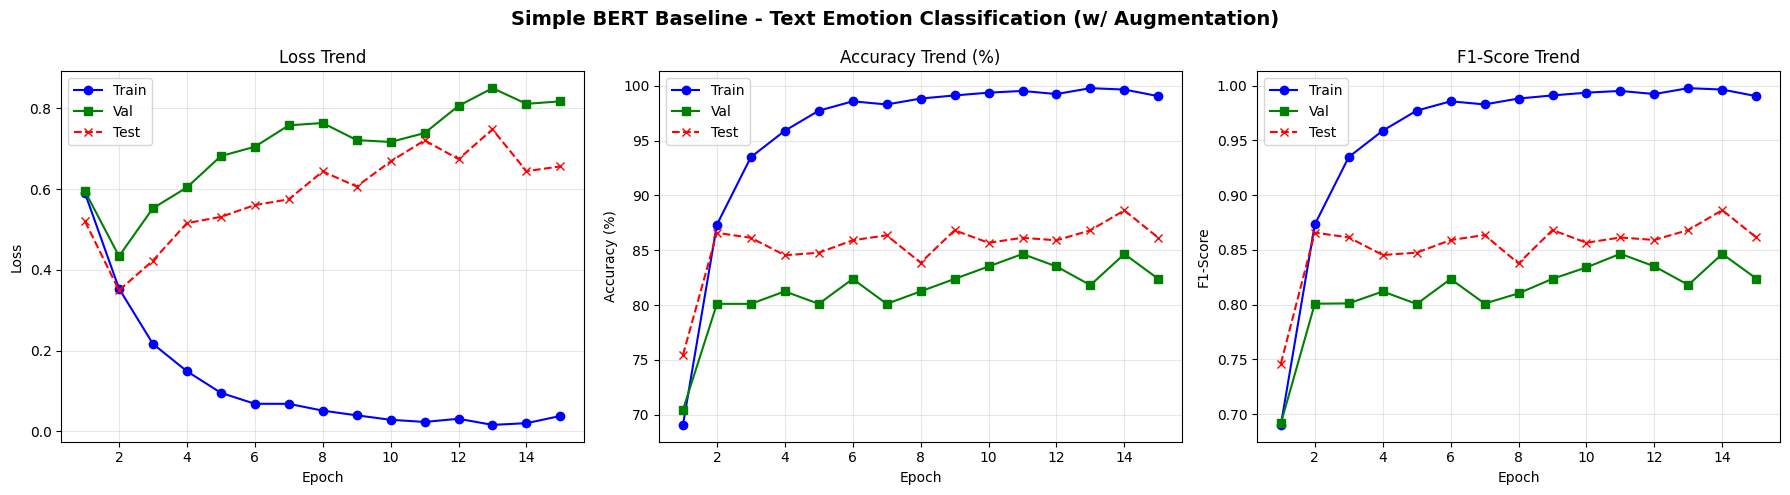

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import nlpaug.augmenter.word as naw
import nltk
import warnings
warnings.filterwarnings('ignore')

# NLTK 리소스 다운로드 (LookupError 방지)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드
text_df = pd.read_csv('mosi_text_metadata.csv')
text_df = text_df.dropna(subset=['text', 'label'])
print(f"총 데이터 수: {len(text_df)}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train / Test 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\n증강 전 Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# ==========================================
# [추가] 데이터 증강 (Train Set에만 적용)
# ==========================================
print("\n데이터 증강 진행 중 (Train 셋에만 적용)...")
aug_syn = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

augmented_tr_texts = []
augmented_tr_labels = []

for text, label in zip(tr_texts, tr_labels):
    # 1. 원본 데이터 추가
    augmented_tr_texts.append(text)
    augmented_tr_labels.append(label)

    # 2. 증강 데이터 생성 및 추가 (결측치 방지)
    if isinstance(text, str) and text.strip() != "":
        aug_text = aug_syn.augment(text)
        if isinstance(aug_text, list):
            aug_text = aug_text[0]

        augmented_tr_texts.append(aug_text)
        augmented_tr_labels.append(label)

# 증강된 데이터로 교체
tr_texts = augmented_tr_texts
tr_labels = augmented_tr_labels

print(f"증강 후 Train 데이터 수: {len(tr_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE   = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts, tr_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TextDataset(te_texts, te_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델:순수 BERT + projection + 분류기
class SimpleBERTClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256):
        super().__init__()
        self.bert       = BertModel.from_pretrained('bert-base-uncased')
        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)   # 멀티모달 fusion용 256차원
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = outputs.pooler_output                        # [B, 768]
        features = self.projection(self.dropout(pooled))        # [B, 256]
        logits   = self.classifier(features)

        if return_features:
            return features
        return logits


# 4. 학습 설정 - Adam 단일 lr
NUM_EPOCHS  = 15
NUM_CLASSES = 2

model     = SimpleBERTClassifier(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total * 100, f1_score(all_targets, all_preds, average='macro')

history = {k: [] for k in ['train_loss', 'val_loss', 'test_loss',
                           'train_acc',  'val_acc',  'test_acc',
                           'train_f1',   'val_f1',   'test_f1']}


print("\n학습 시작")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer, train=True)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,  train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc','val_acc','test_acc',
                     'train_f1','val_f1','test_f1'],
                    [tr_loss, va_loss, te_loss,
                     tr_acc, va_acc, te_acc,
                     tr_f1, va_f1, te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {va_acc:.1f}% (F1 {va_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

print(f"\n✨ 최종 Test Acc: {history['test_acc'][-1]:.1f}% | Test F1: {history['test_f1'][-1]:.4f} ✨")


# 6. 멀티모달 fusion용 256차원 특징 추출 및 저장
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
# 주의: 전체 특징 추출 시에는 원본 데이터(texts)를 사용해야 합니다.
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        feats = model(batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")


# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Simple BERT Baseline - Text Emotion Classification (w/ Augmentation)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## RoBERTa기본 모델 에포크 5

사용 디바이스: cpu
총 데이터 수: 2199

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8792.81it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



학습 시작 (RoBERTa)
Epoch  1 | Train Acc 49.4% (F1 0.4912) | Val Acc 72.7% (F1 0.7202) | Test Acc 73.4% (F1 0.7320)
Epoch  2 | Train Acc 67.5% (F1 0.6753) | Val Acc 76.1% (F1 0.7576) | Test Acc 80.0% (F1 0.7978)
Epoch  3 | Train Acc 78.5% (F1 0.7840) | Val Acc 79.5% (F1 0.7945) | Test Acc 79.8% (F1 0.7975)
Epoch  4 | Train Acc 82.9% (F1 0.8287) | Val Acc 77.8% (F1 0.7784) | Test Acc 81.4% (F1 0.8134)
Epoch  5 | Train Acc 86.3% (F1 0.8629) | Val Acc 80.7% (F1 0.8066) | Test Acc 80.7% (F1 0.8061)

✨ 최종 Test Acc: 80.7% | Test F1: 0.8061 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:58<00:00,  2.38it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


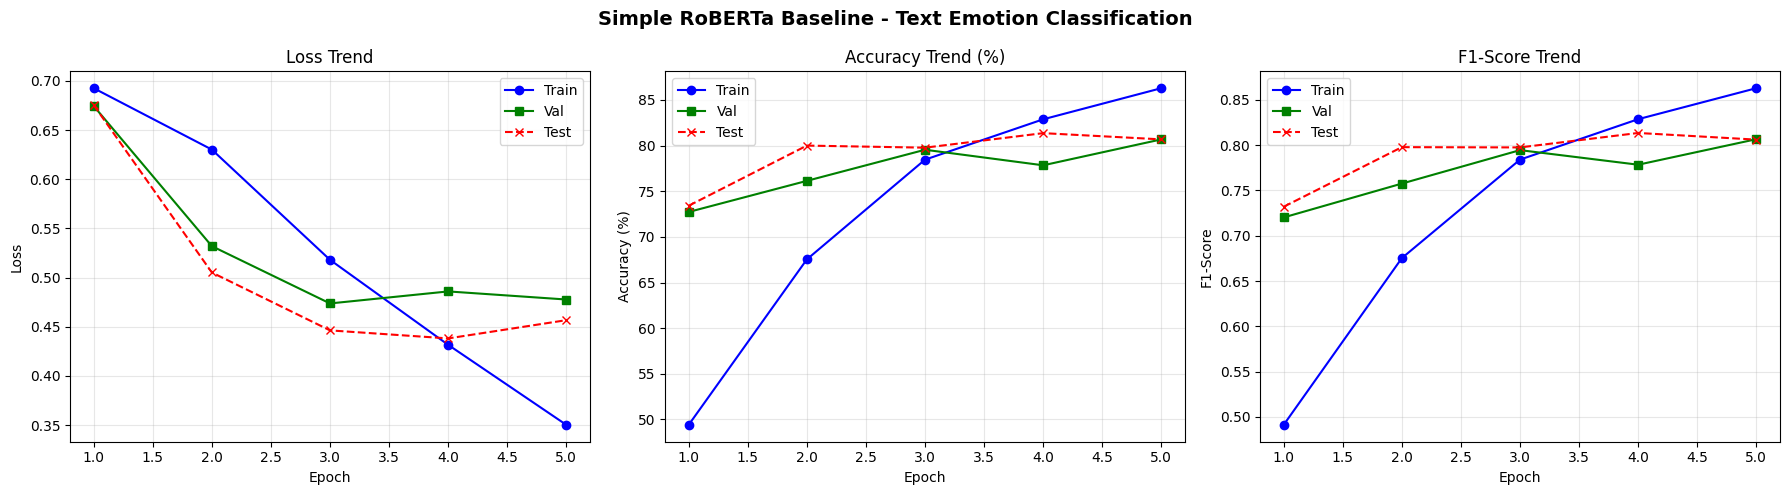

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# [수정 1] RoBERTa 관련 클래스 임포트
from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드
text_df = pd.read_csv('mosi_text_metadata.csv')
text_df = text_df.dropna(subset=['text', 'label'])
print(f"총 데이터 수: {len(text_df)}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train / Test 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
# [수정 2] RobertaTokenizer 로드 ('roberta-base' 사용)
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_TEXT_LEN = 50
BATCH_SIZE   = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts, tr_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TextDataset(te_texts, te_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델: 순수 RoBERTa + projection + 분류기
# [수정 3] 클래스명 및 내부 모델을 RoBERTa로 변경
class SimpleRobertaClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256):
        super().__init__()
        # 'roberta-base' 로드
        self.roberta    = RobertaModel.from_pretrained('roberta-base')
        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)   # 멀티모달 fusion용 256차원
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        # [수정 4] self.bert -> self.roberta 로 호출
        outputs  = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = outputs.pooler_output                        # [B, 768]
        features = self.projection(self.dropout(pooled))        # [B, 256]
        logits   = self.classifier(features)

        if return_features:
            return features
        return logits


# 4. 학습 설정 - Adam 단일 lr
NUM_EPOCHS  = 5
NUM_CLASSES = 2

# [수정 5] 모델 객체 생성 시 변경된 클래스명 사용
model     = SimpleRobertaClassifier(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total * 100, f1_score(all_targets, all_preds, average='macro')

history = {k: [] for k in ['train_loss', 'val_loss', 'test_loss',
                           'train_acc',  'val_acc',  'test_acc',
                           'train_f1',   'val_f1',   'test_f1']}

print("\n학습 시작 (RoBERTa)")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer, train=True)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,  train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc','val_acc','test_acc',
                     'train_f1','val_f1','test_f1'],
                    [tr_loss, va_loss, te_loss,
                     tr_acc, va_acc, te_acc,
                     tr_f1, va_f1, te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {va_acc:.1f}% (F1 {va_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

print(f"\n✨ 최종 Test Acc: {history['test_acc'][-1]:.1f}% | Test F1: {history['test_f1'][-1]:.4f} ✨")


# 6. 멀티모달 fusion용 256차원 특징 추출 및 저장
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        feats = model(batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]


# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Simple RoBERTa Baseline - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## RoBERTa기본 모델 에포크 10

사용 디바이스: cpu
총 데이터 수: 2199

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7852.41it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



학습 시작 (RoBERTa)
Epoch  1 | Train Acc 52.5% (F1 0.5238) | Val Acc 73.9% (F1 0.7374) | Test Acc 73.4% (F1 0.7341)
Epoch  2 | Train Acc 71.7% (F1 0.7165) | Val Acc 76.1% (F1 0.7509) | Test Acc 78.9% (F1 0.7853)
Epoch  3 | Train Acc 80.9% (F1 0.8091) | Val Acc 78.4% (F1 0.7841) | Test Acc 81.8% (F1 0.8181)
Epoch  4 | Train Acc 86.9% (F1 0.8685) | Val Acc 76.1% (F1 0.7613) | Test Acc 82.5% (F1 0.8248)
Epoch  5 | Train Acc 89.6% (F1 0.8956) | Val Acc 73.9% (F1 0.7381) | Test Acc 79.3% (F1 0.7931)
Epoch  6 | Train Acc 91.5% (F1 0.9147) | Val Acc 77.8% (F1 0.7781) | Test Acc 82.7% (F1 0.8273)
Epoch  7 | Train Acc 93.7% (F1 0.9368) | Val Acc 77.8% (F1 0.7783) | Test Acc 80.2% (F1 0.8015)
Epoch  8 | Train Acc 96.1% (F1 0.9615) | Val Acc 77.3% (F1 0.7727) | Test Acc 81.4% (F1 0.8135)
Epoch  9 | Train Acc 96.3% (F1 0.9633) | Val Acc 73.3% (F1 0.7329) | Test Acc 79.5% (F1 0.7950)
Epoch 10 | Train Acc 97.5% (F1 0.9747) | Val Acc 77.3% (F1 0.7708) | Test Acc 80.2% (F1 0.8020)

✨ 최종 Test Acc: 80.2% |

특징 추출: 100%|██████████| 138/138 [00:48<00:00,  2.86it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


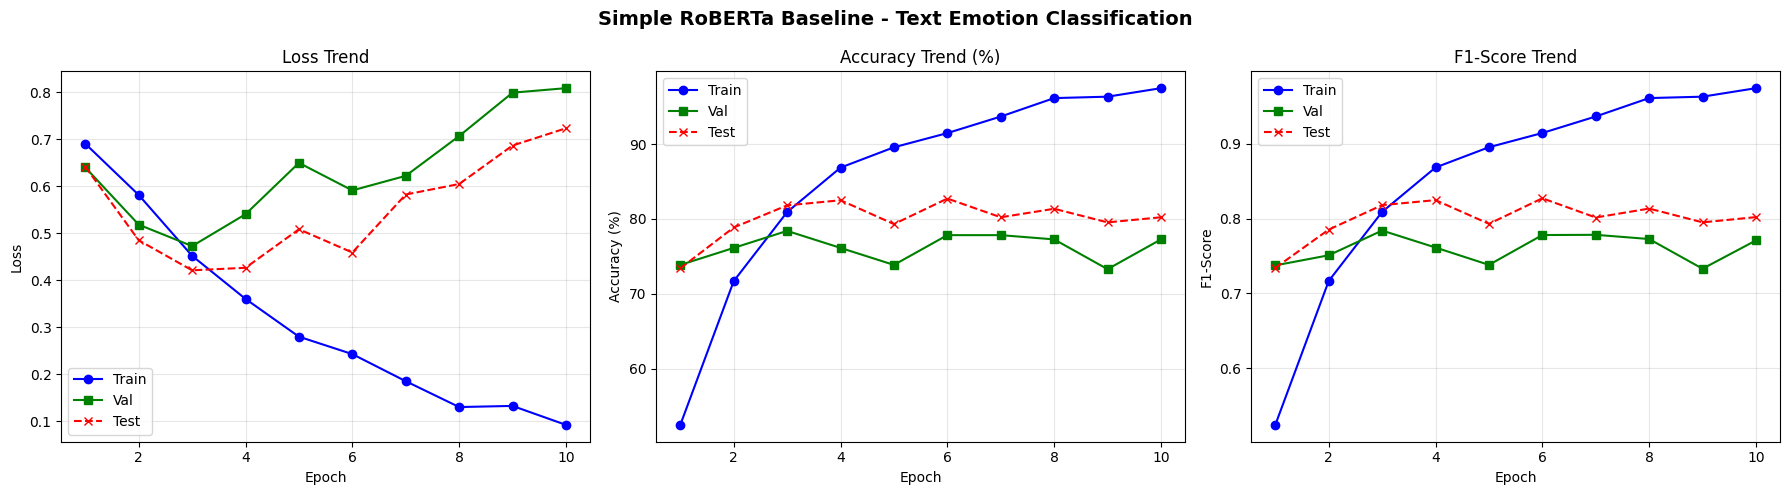

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# [수정 1] RoBERTa 관련 클래스 임포트
from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드
text_df = pd.read_csv('mosi_text_metadata.csv')
text_df = text_df.dropna(subset=['text', 'label'])
print(f"총 데이터 수: {len(text_df)}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train / Test 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
# [수정 2] RobertaTokenizer 로드 ('roberta-base' 사용)
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
MAX_TEXT_LEN = 50
BATCH_SIZE   = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts, tr_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TextDataset(te_texts, te_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# 3. 모델: 순수 RoBERTa + projection + 분류기
# [수정 3] 클래스명 및 내부 모델을 RoBERTa로 변경
class SimpleRobertaClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256):
        super().__init__()
        # 'roberta-base' 로드
        self.roberta    = RobertaModel.from_pretrained('roberta-base')
        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)   # 멀티모달 fusion용 256차원
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        # [수정 4] self.bert -> self.roberta 로 호출
        outputs  = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = outputs.pooler_output                        # [B, 768]
        features = self.projection(self.dropout(pooled))        # [B, 256]
        logits   = self.classifier(features)

        if return_features:
            return features
        return logits


# 4. 학습 설정 - Adam 단일 lr
NUM_EPOCHS  = 10
NUM_CLASSES = 2

# [수정 5] 모델 객체 생성 시 변경된 클래스명 사용
model     = SimpleRobertaClassifier(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    return total_loss / total, correct / total * 100, f1_score(all_targets, all_preds, average='macro')

history = {k: [] for k in ['train_loss', 'val_loss', 'test_loss',
                           'train_acc',  'val_acc',  'test_acc',
                           'train_f1',   'val_f1',   'test_f1']}

print("\n학습 시작 (RoBERTa)")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer, train=True)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader,  train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc','val_acc','test_acc',
                     'train_f1','val_f1','test_f1'],
                    [tr_loss, va_loss, te_loss,
                     tr_acc, va_acc, te_acc,
                     tr_f1, va_f1, te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {va_acc:.1f}% (F1 {va_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

print(f"\n✨ 최종 Test Acc: {history['test_acc'][-1]:.1f}% | Test F1: {history['test_f1'][-1]:.4f} ✨")


# 6. 멀티모달 fusion용 256차원 특징 추출 및 저장
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        feats = model(batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]


# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Simple RoBERTa Baseline - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# 레이어 동결 + 파인튜닝+ 조기종료

/home/dltndus0628/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 디바이스: cuda
결측치 제거 전: 2199
결측치 제거 후: 2199
레이블 분포:
label
0    1119
1    1080
Name: count, dtype: int64

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6389.06it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝
Epoch  1 | Train Acc 60.3% (F1 0.6032) | Val Acc 71.0% (F1 0.7091) | Test Acc 72.7% (F1 0.7271)
Epoch  2 | Train Acc 76.7% (F1 0.7668) | Val Acc 75.0% (F1 0.7488) | Test Acc 83.2% (F1 0.8317)
Epoch  3 | Train Acc 83.4% (F1 0.8339) | Val Acc 77.3% (F1 0.7717) | Test Acc 83.0% (F1 0.8290)
Epoch  4 | Train Acc 87.8% (F1 0.8781) | Val Acc 81.8% (F1 0.8178) | Test Acc 84.1% (F1 0.8405)
Epoch  5 | Train Acc 89.6% (F1 0.8958) | Val Acc 81.8% (F1 0.8182) | Test Acc 84.1% (F1 0.8409)
Epoch  6 | Train Acc 93.3% (F1 0.9330) | Val Acc 82.4% (F1 0.8232) | Test Acc 81.8% (F1 0.8168)

⏹ Early Stopping at epoch 6 (val_loss not improved for 2 epochs)
✅ 최적 모델 복원 완료 (Best Val Loss: 0.4619)

✨ 최종 Test Acc: 84.1% | Test F1: 0.8405 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:02<00:00, 61.57it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


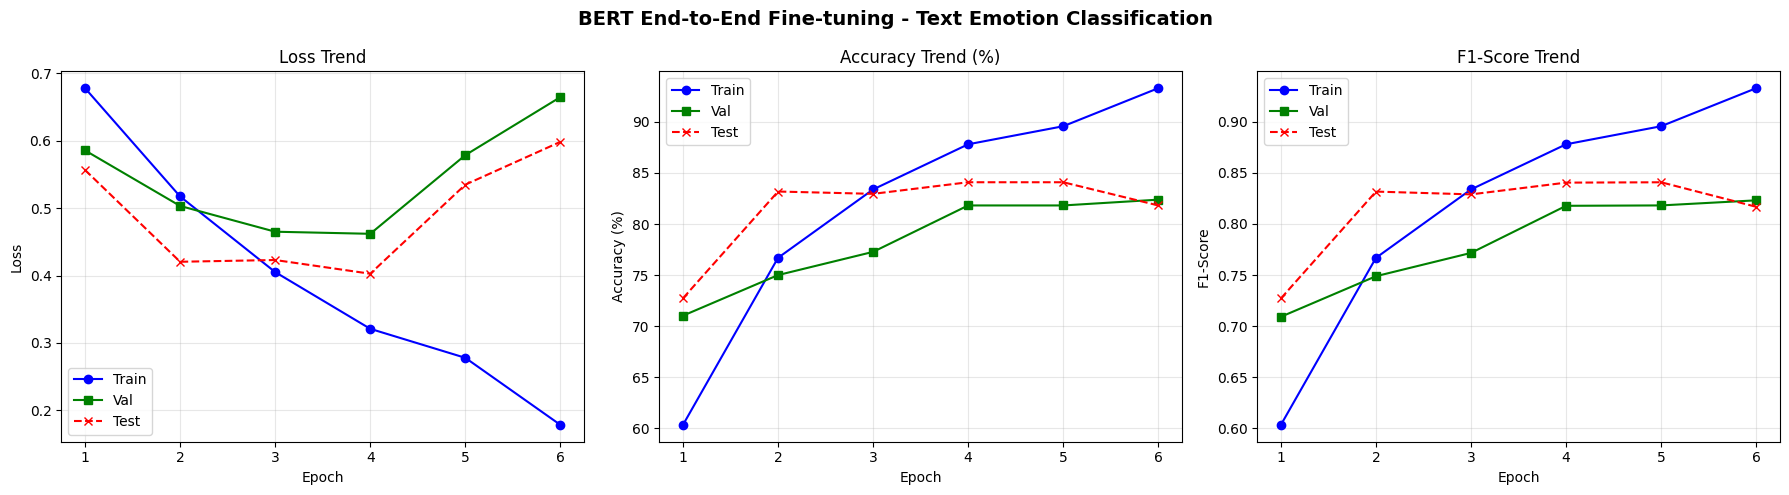

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드 및 전처리
text_df = pd.read_csv('mosi_text_metadata.csv')
print(f"결측치 제거 전: {len(text_df)}")
text_df = text_df.dropna(subset=['text', 'label'])
print(f"결측치 제거 후: {len(text_df)}")
print(f"레이블 분포:\n{text_df['label'].value_counts()}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()


# Train/Val/Test로 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
#val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }



train_loader = DataLoader(TextDataset(tr_texts,  tr_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(te_texts,  te_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 : BERT + projection + 분류기
class TEXTEncoderWithClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, freeze_bert_layers=6):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # BERT 하위 레이어 동결: 전체 파인튜닝 대신 상위 레이어만 학습
        # 이유: 데이터가 적을 때(~1700개) 전체 파인튜닝은 과적합 위험
        #       하위 레이어(알바벳조합, 기초적인 영문법 등 기초 언어 지식)는 범용 언어 지식 → 동결, 상위 레이어(복잡한 의미- 감정 담당)만 감정 태스크에 적응
        for name, param in self.bert.named_parameters(): # BERT안에 있는 이름,파라미터 꺼냄
            layer_num = None
            for part in name.split('.'):#encoder.layer.3.attention -> ['encoder', 'layer', '3', 'attention']
                if part.isdigit(): #숫자만 통과 EX) 3
                    layer_num = int(part) #숫자 저장
                    break
            if layer_num is not None and layer_num < freeze_bert_layers: #숫자이고 6보다 작으면 동결
                param.requires_grad = False

        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)          # 멀티모달 fusion용 256차원

        # [수정 6] LayerNorm 추가: projection 후 안정적인 표현 학습
        # self.layer_norm = nn.LayerNorm(proj_dim)

        # 분류기 헤드
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled       = outputs.pooler_output                     # [B, 768]
        features     = self.projection(self.dropout(pooled))  # [B, 256]
        logits       = self.classifier(features)

        if return_features:                                      # 멀티모달 fusion 시 사용
            return features
        return logits


# 4. 학습 설정
NUM_EPOCHS = 15
NUM_CLASSES = 2

model = TEXTEncoderWithClassifier(num_classes=NUM_CLASSES).to(device)


# 동결되지 않은 상위 레이어 bert 인코더 부분 학습
bert_params       = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]

#분류기 학습
non_bert_params   = [p for n, p in model.named_parameters() if 'bert' not in n]

optimizer = optim.AdamW([
    {'params': bert_params,     'lr': 1e-5, 'weight_decay': 0.01},
    {'params': non_bert_params, 'lr': 1e-3, 'weight_decay': 0.01}
])
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    """Train 또는 Eval 한 에포크 실행"""
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch  = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad() #기울기 0으로 초기화
                loss.backward()
                # [수정 9] Gradient Clipping: BERT 파인튜닝 시 필수
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total * 100
    f1       = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, acc, f1


history = {k: [] for k in ['train_loss','val_loss','test_loss',
                             'train_acc', 'val_acc', 'test_acc',
                             'train_f1',  'val_f1',  'test_f1']}

# [수정 10] Early Stopping 추가
best_val_loss = float('inf')
patience       = 2
patience_count = 0
best_state     = None

print("\n파인튜닝")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer,  train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc', 'val_acc', 'test_acc',
                     'train_f1',  'val_f1',  'test_f1'],
                    [tr_loss, vl_loss, te_loss,
                     tr_acc,  vl_acc,  te_acc,
                     tr_f1,   vl_f1,   te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {vl_acc:.1f}% (F1 {vl_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    # Early Stopping 체크
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
            break

# 최적 가중치 복원
if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

# 최종 테스트
te_loss, te_acc, te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {te_acc:.1f}% | Test F1: {te_f1:.4f} ✨")

# ──────────────────────────────────────────────
# 6. 멀티모달 fusion을 위한 256차원 특징 추출
# ──────────────────────────────────────────────
# 학습이 완료된 encoder에서 의미 있는 256차원 벡터 추출

print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = model(input_ids, attention_mask, return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]

# 저장 (멀티모달 fusion에서 로드해서 사용)
# torch.save({'features': X_text, 'labels': y_text}, 'text_features_256.pt')
# torch.save(model.state_dict(), 'text_encoder_best.pt')
# print("저장 완료: text_features_256.pt | text_encoder_best.pt")

# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('BERT End-to-End Fine-tuning - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
# plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
# print("그래프 저장 완료: training_results.png")

- 전체적으로 과적합이 너무 심함
- 데이터 증강을 하던가 모델을 아예 바꾸던가 필요할 것 같음
- 학습률 바꾸고 dropout을 써도 크게 과적합이 사라지지는 않음

## 레이어 동결 변경
- 레이어 동결 10으로 설정했을 때 안정적

사용 디바이스: cuda
결측치 제거 전: 2199
결측치 제거 후: 2199
레이블 분포:
label
0    1119
1    1080
Name: count, dtype: int64

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6145.61it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝
Epoch  1 | Train Acc 54.5% (F1 0.5445) | Val Acc 65.9% (F1 0.6442) | Test Acc 69.5% (F1 0.6897)
Epoch  2 | Train Acc 69.7% (F1 0.6961) | Val Acc 73.3% (F1 0.7327) | Test Acc 78.4% (F1 0.7840)
Epoch  3 | Train Acc 77.4% (F1 0.7738) | Val Acc 75.6% (F1 0.7550) | Test Acc 80.9% (F1 0.8083)
Epoch  4 | Train Acc 80.5% (F1 0.8047) | Val Acc 76.1% (F1 0.7568) | Test Acc 81.8% (F1 0.8165)
Epoch  5 | Train Acc 81.4% (F1 0.8142) | Val Acc 78.4% (F1 0.7831) | Test Acc 83.2% (F1 0.8314)
Epoch  6 | Train Acc 84.3% (F1 0.8425) | Val Acc 80.7% (F1 0.8043) | Test Acc 83.6% (F1 0.8355)

⏹ Early Stopping at epoch 6 (val_loss not improved for 2 epochs)
✅ 최적 모델 복원 완료 (Best Val Loss: 0.4752)

✨ 최종 Test Acc: 81.8% | Test F1: 0.8165 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:02<00:00, 60.60it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


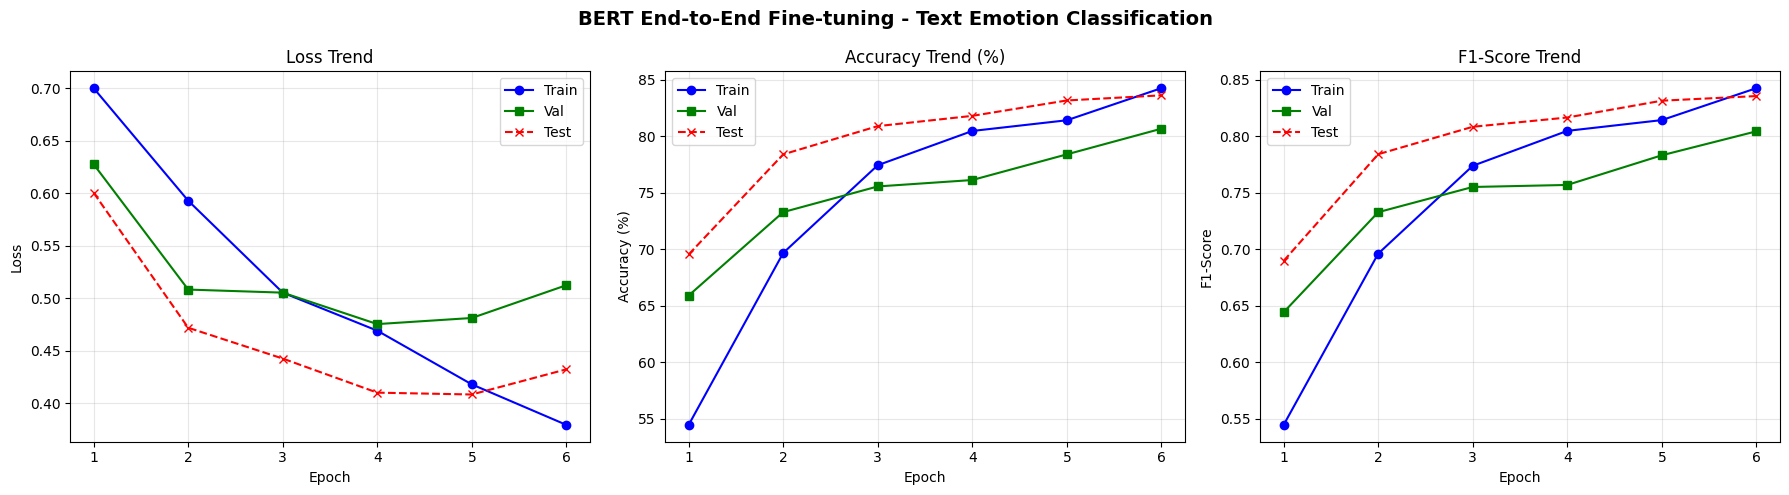

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드 및 전처리
text_df = pd.read_csv('mosi_text_metadata.csv')
print(f"결측치 제거 전: {len(text_df)}")
text_df = text_df.dropna(subset=['text', 'label'])
print(f"결측치 제거 후: {len(text_df)}")
print(f"레이블 분포:\n{text_df['label'].value_counts()}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()


# Train/Val/Test로 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
#val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }



train_loader = DataLoader(TextDataset(tr_texts,  tr_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(te_texts,  te_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 : BERT + projection + 분류기
class TEXTEncoderWithClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, freeze_bert_layers=10):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # BERT 하위 레이어 동결: 전체 파인튜닝 대신 상위 레이어만 학습
        # 이유: 데이터가 적을 때(~1700개) 전체 파인튜닝은 과적합 위험
        #       하위 레이어(알바벳조합, 기초적인 영문법 등 기초 언어 지식)는 범용 언어 지식 → 동결, 상위 레이어(복잡한 의미- 감정 담당)만 감정 태스크에 적응
        for name, param in self.bert.named_parameters(): # BERT안에 있는 이름,파라미터 꺼냄
            layer_num = None
            for part in name.split('.'):#encoder.layer.3.attention -> ['encoder', 'layer', '3', 'attention']
                if part.isdigit(): #숫자만 통과 EX) 3
                    layer_num = int(part) #숫자 저장
                    break
            if layer_num is not None and layer_num < freeze_bert_layers: #숫자이고 6보다 작으면 동결
                param.requires_grad = False

        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)          # 멀티모달 fusion용 256차원

        # [수정 6] LayerNorm 추가: projection 후 안정적인 표현 학습
        # self.layer_norm = nn.LayerNorm(proj_dim)

        # 분류기 헤드
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled       = outputs.pooler_output                     # [B, 768]
        features     = self.projection(self.dropout(pooled))  # [B, 256]
        logits       = self.classifier(features)

        if return_features:                                      # 멀티모달 fusion 시 사용
            return features
        return logits


# 4. 학습 설정
NUM_EPOCHS = 15
NUM_CLASSES = 2

model = TEXTEncoderWithClassifier(num_classes=NUM_CLASSES).to(device)


# 동결되지 않은 상위 레이어 bert 인코더 부분 학습
bert_params       = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]

#분류기 학습
non_bert_params   = [p for n, p in model.named_parameters() if 'bert' not in n]

optimizer = optim.AdamW([
    {'params': bert_params,     'lr': 1e-5, 'weight_decay': 0.01},
    {'params': non_bert_params, 'lr': 1e-3, 'weight_decay': 0.01}
])
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    """Train 또는 Eval 한 에포크 실행"""
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch  = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad() #기울기 0으로 초기화
                loss.backward()
                # [수정 9] Gradient Clipping: BERT 파인튜닝 시 필수
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total * 100
    f1       = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, acc, f1


history = {k: [] for k in ['train_loss','val_loss','test_loss',
                             'train_acc', 'val_acc', 'test_acc',
                             'train_f1',  'val_f1',  'test_f1']}

# [수정 10] Early Stopping 추가
best_val_loss = float('inf')
patience       = 2
patience_count = 0
best_state     = None

print("\n파인튜닝")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer,  train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc', 'val_acc', 'test_acc',
                     'train_f1',  'val_f1',  'test_f1'],
                    [tr_loss, vl_loss, te_loss,
                     tr_acc,  vl_acc,  te_acc,
                     tr_f1,   vl_f1,   te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {vl_acc:.1f}% (F1 {vl_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    # Early Stopping 체크
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
            break

# 최적 가중치 복원
if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

# 최종 테스트
te_loss, te_acc, te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {te_acc:.1f}% | Test F1: {te_f1:.4f} ✨")

# ──────────────────────────────────────────────
# 6. 멀티모달 fusion을 위한 256차원 특징 추출
# ──────────────────────────────────────────────
# 학습이 완료된 encoder에서 의미 있는 256차원 벡터 추출

print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = model(input_ids, attention_mask, return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]

# 저장 (멀티모달 fusion에서 로드해서 사용)
# torch.save({'features': X_text, 'labels': y_text}, 'text_features_256.pt')
# torch.save(model.state_dict(), 'text_encoder_best.pt')
# print("저장 완료: text_features_256.pt | text_encoder_best.pt")

# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('BERT End-to-End Fine-tuning - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
# plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
# print("그래프 저장 완료: training_results.png")

# 레이어 동결 + 파인튜닝+ 조기종료 + 유의어 교체(데이터 증강)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


사용 디바이스: cpu
결측치 제거 전: 2199
결측치 제거 후: 2199
레이블 분포:
label
0    1119
1    1080
Name: count, dtype: int64

증강 전 Train: 1583 | Val: 176 | Test: 440

데이터 증강 진행 중 (Train 셋에만 적용)...
증강 후 Train 데이터 수: 3166


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5177.61it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝 시작
Epoch  1 | Train Acc 59.6% (F1 0.5961) | Val Acc 73.3% (F1 0.7325) | Test Acc 73.6% (F1 0.7346)
Epoch  2 | Train Acc 77.4% (F1 0.7735) | Val Acc 78.4% (F1 0.7813) | Test Acc 80.9% (F1 0.8075)
Epoch  3 | Train Acc 81.3% (F1 0.8125) | Val Acc 78.4% (F1 0.7841) | Test Acc 82.7% (F1 0.8273)
Epoch  4 | Train Acc 84.2% (F1 0.8416) | Val Acc 79.0% (F1 0.7897) | Test Acc 82.7% (F1 0.8272)
Epoch  5 | Train Acc 86.6% (F1 0.8657) | Val Acc 80.7% (F1 0.8056) | Test Acc 84.3% (F1 0.8428)

⏹ Early Stopping at epoch 5 (val_loss not improved for 2 epochs)
✅ 최적 모델 복원 완료 (Best Val Loss: 0.4601)

✨ 최종 Test Acc: 82.7% | Test F1: 0.8273 ✨

─── 멀티모달 fusion용 256차원 특징 추출 ───


특징 추출: 100%|██████████| 138/138 [00:48<00:00,  2.85it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


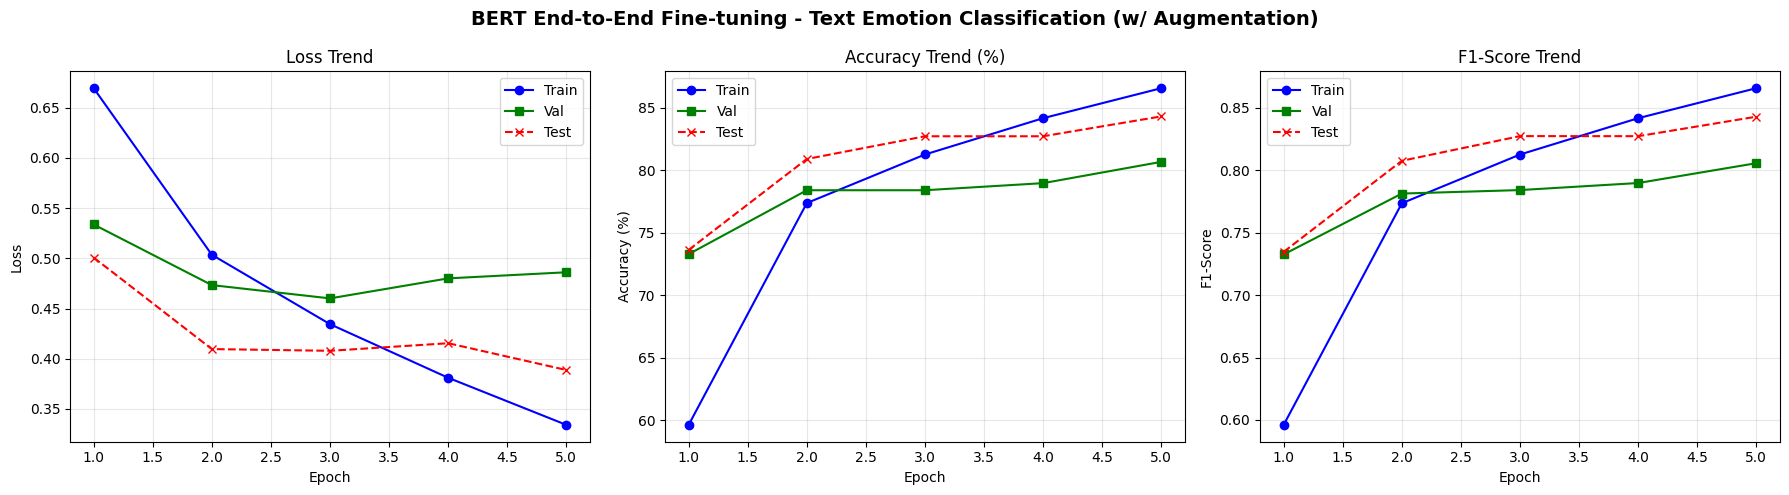

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import nlpaug.augmenter.word as naw
import nltk
import warnings
warnings.filterwarnings('ignore')

# 최초 1회 NLTK WordNet 데이터 다운로드 필요
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')    # 에러 해결 핵심!
nltk.download('averaged_perceptron_tagger_eng') # 최신 NLTK 버전 대응용
nltk.download('punkt')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
text_df = pd.read_csv('mosi_text_metadata.csv')
print(f"결측치 제거 전: {len(text_df)}")
text_df = text_df.dropna(subset=['text', 'label'])
print(f"결측치 제거 후: {len(text_df)}")
print(f"레이블 분포:\n{text_df['label'].value_counts()}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()

# Train/Val/Test로 분할 (원본 데이터 기준)
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
# val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\n증강 전 Train: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")

# ==========================================
# [추가] 데이터 증강 (Train Set에만 적용!)
# ==========================================
print("\n데이터 증강 진행 중 (Train 셋에만 적용)...")
# aug_p: 변경 확률(10~20% 권장)
aug_syn = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

augmented_tr_texts = []
augmented_tr_labels = []

# 원본 Train 데이터도 유지하면서, 증강된 데이터를 추가합니다.
for text, label in zip(tr_texts, tr_labels):
    # 1. 원본 데이터 추가
    augmented_tr_texts.append(text)
    augmented_tr_labels.append(label)

    # 2. 증강 데이터 생성 및 추가 (1배수 증강 예시)
    if isinstance(text, str) and text.strip() != "":
        aug_text = aug_syn.augment(text)
        # nlpaug 버전에 따라 리스트로 반환될 수 있으므로 문자열로 추출
        if isinstance(aug_text, list):
            aug_text = aug_text[0]

        augmented_tr_texts.append(aug_text)
        augmented_tr_labels.append(label)

# 증강된 데이터로 교체
tr_texts = augmented_tr_texts
tr_labels = augmented_tr_labels

print(f"증강 후 Train 데이터 수: {len(tr_texts)}")


# ==========================================
# 2. 데이터셋 및 데이터로더
# ==========================================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(TextDataset(tr_texts,  tr_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(te_texts,  te_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 모델 : BERT + projection + 분류기
# ==========================================
class TEXTEncoderWithClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, freeze_bert_layers=10):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # BERT 하위 레이어 동결
        for name, param in self.bert.named_parameters():
            layer_num = None
            for part in name.split('.'):
                if part.isdigit():
                    layer_num = int(part)
                    break
            if layer_num is not None and layer_num < freeze_bert_layers:
                param.requires_grad = False

        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)

        # 분류기 헤드
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled       = outputs.pooler_output                     # [B, 768]
        features     = self.projection(self.dropout(pooled))  # [B, 256]
        logits       = self.classifier(features)

        if return_features:
            return features
        return logits

# ==========================================
# 4. 학습 설정
# ==========================================
NUM_EPOCHS = 15
NUM_CLASSES = 2

model = TEXTEncoderWithClassifier(num_classes=NUM_CLASSES).to(device)

bert_params       = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
non_bert_params   = [p for n, p in model.named_parameters() if 'bert' not in n]

optimizer = optim.AdamW([
    {'params': bert_params,     'lr': 1e-5, 'weight_decay': 0.01},
    {'params': non_bert_params, 'lr': 1e-3, 'weight_decay': 0.01}
])
criterion = nn.CrossEntropyLoss()

# ==========================================
# 5. 학습 루프
# ==========================================
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch  = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total * 100
    f1       = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, acc, f1

history = {k: [] for k in ['train_loss','val_loss','test_loss',
                             'train_acc', 'val_acc', 'test_acc',
                             'train_f1',  'val_f1',  'test_f1']}

best_val_loss = float('inf')
patience       = 2
patience_count = 0
best_state     = None

print("\n파인튜닝 시작")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer,  train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc', 'val_acc', 'test_acc',
                     'train_f1',  'val_f1',  'test_f1'],
                    [tr_loss, vl_loss, te_loss,
                     tr_acc,  vl_acc,  te_acc,
                     tr_f1,   vl_f1,   te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {vl_acc:.1f}% (F1 {vl_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
            break

if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

te_loss, te_acc, te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {te_acc:.1f}% | Test F1: {te_f1:.4f} ✨")

# ==========================================
# 6. 멀티모달 fusion을 위한 특징 추출
# ==========================================
print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
# 주의: 전체 특징 추출 시에는 원본 데이터(texts)를 사용해야 인덱스가 맞습니다.
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = model(input_ids, attention_mask, return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")

# ==========================================
# 7. 시각화
# ==========================================
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('BERT End-to-End Fine-tuning - Text Emotion Classification (w/ Augmentation)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 레이어 전체 동결

- 레이어 전체 동결 시 성능 안나옴

사용 디바이스: cuda
결측치 제거 전: 2199
결측치 제거 후: 2199
레이블 분포:
label
0    1119
1    1080
Name: count, dtype: int64

Train: 1583 | Val: 176 | Test: 440


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5081.90it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



파인튜닝
Epoch  1 | Train Acc 49.2% (F1 0.4921) | Val Acc 51.1% (F1 0.3383) | Test Acc 50.9% (F1 0.3373)
Epoch  2 | Train Acc 51.1% (F1 0.5111) | Val Acc 48.9% (F1 0.3282) | Test Acc 49.1% (F1 0.3293)
Epoch  3 | Train Acc 51.0% (F1 0.5048) | Val Acc 55.7% (F1 0.4940) | Test Acc 58.2% (F1 0.5234)
Epoch  4 | Train Acc 54.1% (F1 0.5375) | Val Acc 56.8% (F1 0.5156) | Test Acc 59.8% (F1 0.5487)
Epoch  5 | Train Acc 56.3% (F1 0.5634) | Val Acc 64.8% (F1 0.6323) | Test Acc 63.6% (F1 0.6264)
Epoch  6 | Train Acc 57.4% (F1 0.5742) | Val Acc 62.5% (F1 0.6153) | Test Acc 65.9% (F1 0.6492)
Epoch  7 | Train Acc 59.9% (F1 0.5987) | Val Acc 66.5% (F1 0.6285) | Test Acc 65.2% (F1 0.6207)
Epoch  8 | Train Acc 60.7% (F1 0.6071) | Val Acc 67.6% (F1 0.6683) | Test Acc 67.0% (F1 0.6595)
Epoch  9 | Train Acc 62.2% (F1 0.6222) | Val Acc 69.9% (F1 0.6986) | Test Acc 70.5% (F1 0.7042)
Epoch 10 | Train Acc 62.6% (F1 0.6250) | Val Acc 60.2% (F1 0.5538) | Test Acc 62.7% (F1 0.5826)

⏹ Early Stopping at epoch 10 (val

특징 추출: 100%|██████████| 138/138 [00:02<00:00, 62.03it/s]


추출 완료! X_text shape: torch.Size([2199, 256])


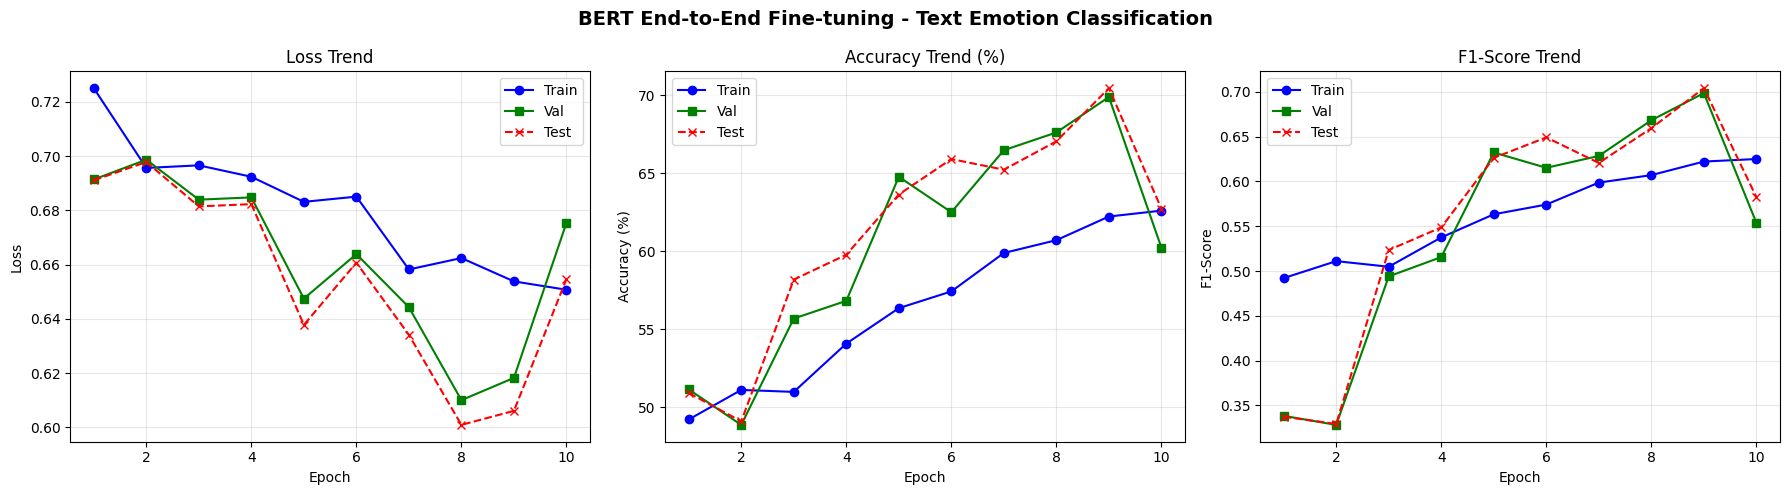

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


# 1. 데이터 로드 및 전처리
text_df = pd.read_csv('mosi_text_metadata.csv')
print(f"결측치 제거 전: {len(text_df)}")
text_df = text_df.dropna(subset=['text', 'label'])
print(f"결측치 제거 후: {len(text_df)}")
print(f"레이블 분포:\n{text_df['label'].value_counts()}")

texts = text_df['text'].tolist()
labels = text_df['label'].tolist()


# Train/Val/Test로 분할
tr_texts, te_texts, tr_labels, te_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
#val 분할
tr_texts, val_texts, tr_labels, val_labels = train_test_split(
    tr_texts, tr_labels, test_size=0.1, random_state=42, stratify=tr_labels
)
print(f"\nTrain: {len(tr_texts)} | Val: {len(val_texts)} | Test: {len(te_texts)}")


# 2. 데이터셋
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_TEXT_LEN = 50
BATCH_SIZE = 16

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts   = texts
        self.labels  = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }



train_loader = DataLoader(TextDataset(tr_texts,  tr_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(val_texts, val_labels, tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(te_texts,  te_labels,  tokenizer, MAX_TEXT_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)


# 3. 모델 : BERT + projection + 분류기
class TEXTEncoderWithClassifier(nn.Module):
    def __init__(self, num_classes=2, proj_dim=256, freeze_bert_layers=10):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # BERT  레이어 동결
        for param in self.bert.parameters():
            param.requires_grad = False

        self.dropout    = nn.Dropout(0.3)
        self.projection = nn.Linear(768, proj_dim)          # 멀티모달 fusion용 256차원

        # [수정 6] LayerNorm 추가: projection 후 안정적인 표현 학습
        # self.layer_norm = nn.LayerNorm(proj_dim)

        # 분류기 헤드
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, return_features=False):
        outputs      = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled       = outputs.pooler_output                     # [B, 768]
        features     = self.projection(self.dropout(pooled))  # [B, 256]
        logits       = self.classifier(features)

        if return_features:                                      # 멀티모달 fusion 시 사용
            return features
        return logits


# 4. 학습 설정
NUM_EPOCHS = 15
NUM_CLASSES = 2

model = TEXTEncoderWithClassifier(num_classes=NUM_CLASSES).to(device)
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.AdamW(trainable_params, lr=1e-3, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()


# 5. 학습 루프
def run_epoch(model, loader, optimizer=None, train=True):
    """Train 또는 Eval 한 에포크 실행"""
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids     = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch  = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels_batch)

            if train:
                optimizer.zero_grad() #기울기 0으로 초기화
                loss.backward()
                # [수정 9] Gradient Clipping: BERT 파인튜닝 시 필수
                # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * labels_batch.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += labels_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total * 100
    f1       = f1_score(all_targets, all_preds, average='macro')
    return avg_loss, acc, f1


history = {k: [] for k in ['train_loss','val_loss','test_loss',
                             'train_acc', 'val_acc', 'test_acc',
                             'train_f1',  'val_f1',  'test_f1']}

# [수정 10] Early Stopping 추가
best_val_loss = float('inf')
patience       = 2
patience_count = 0
best_state     = None


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer,  train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   train=False)
    te_loss, te_acc, te_f1 = run_epoch(model, test_loader,  train=False)

    for k, v in zip(['train_loss','val_loss','test_loss',
                     'train_acc', 'val_acc', 'test_acc',
                     'train_f1',  'val_f1',  'test_f1'],
                    [tr_loss, vl_loss, te_loss,
                     tr_acc,  vl_acc,  te_acc,
                     tr_f1,   vl_f1,   te_f1]):
        history[k].append(v)

    print(f"Epoch {epoch:2d} | "
          f"Train Acc {tr_acc:.1f}% (F1 {tr_f1:.4f}) | "
          f"Val Acc {vl_acc:.1f}% (F1 {vl_f1:.4f}) | "
          f"Test Acc {te_acc:.1f}% (F1 {te_f1:.4f})")

    # Early Stopping 체크
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\n⏹ Early Stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
            break

# 최적 가중치 복원
if best_state:
    model.load_state_dict(best_state)
    print(f"✅ 최적 모델 복원 완료 (Best Val Loss: {best_val_loss:.4f})")

# 최종 테스트
te_loss, te_acc, te_f1 = run_epoch(model, test_loader, train=False)
print(f"\n✨ 최종 Test Acc: {te_acc:.1f}% | Test F1: {te_f1:.4f} ✨")

# ──────────────────────────────────────────────
# 6. 멀티모달 fusion을 위한 256차원 특징 추출
# ──────────────────────────────────────────────
# 학습이 완료된 encoder에서 의미 있는 256차원 벡터 추출

print("\n─── 멀티모달 fusion용 256차원 특징 추출 ───")
all_dataset = TextDataset(texts, labels, tokenizer, MAX_TEXT_LEN)
all_loader  = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_features, all_labels_out = [], []
with torch.no_grad():
    for batch in tqdm(all_loader, desc="특징 추출"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = model(input_ids, attention_mask, return_features=True)
        all_features.append(feats.cpu())
        all_labels_out.append(batch['label'])

X_text = torch.cat(all_features, dim=0)
y_text = torch.cat(all_labels_out, dim=0)
print(f"추출 완료! X_text shape: {X_text.shape}")  # [2199, 256]

# 저장 (멀티모달 fusion에서 로드해서 사용)
# torch.save({'features': X_text, 'labels': y_text}, 'text_features_256.pt')
# torch.save(model.state_dict(), 'text_encoder_best.pt')
# print("저장 완료: text_features_256.pt | text_encoder_best.pt")

# ──────────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────────
actual_epochs = len(history['train_loss'])
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'g-s', label='Val')
axes[0].plot(epochs, history['test_loss'],  'r--x', label='Test')
axes[0].set_title('Loss Trend'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'g-s', label='Val')
axes[1].plot(epochs, history['test_acc'],  'r--x', label='Test')
axes[1].set_title('Accuracy Trend (%)'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(epochs, history['train_f1'], 'b-o', label='Train')
axes[2].plot(epochs, history['val_f1'],   'g-s', label='Val')
axes[2].plot(epochs, history['test_f1'],  'r--x', label='Test')
axes[2].set_title('F1-Score Trend'); axes[2].set_ylabel('F1-Score')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('BERT End-to-End Fine-tuning - Text Emotion Classification',
             fontsize=14, fontweight='bold')
fig.tight_layout()
# plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()
# print("그래프 저장 완료: training_results.png")